# ODM 2025 – Exercise Sheet 6: Vergleich von Multi-Objective Optimization Algorithmen

In diesem Notebook werden verschiedene MOO-Algorithmen auf die binäre bi-objektive Funktion (Function7) angewendet und anhand verschiedener Qualitätsmetriken verglichen:

**Algorithmen:**
- NSGA-II (Non-dominated Sorting Genetic Algorithm II)
- SMS-EMOA (S-Metric Selection EMOA)
- MOEA/D (Multi-Objective Evolutionary Algorithm based on Decomposition)

**Metriken:**
- Hypervolume (HV)
- Inverted Generational Distance (IGD)
- Generational Distance (GD)


## VPN Reminder

The black-box service is only available when **connected to the Uni Münster VPN**!


## 1. Setup und Imports


In [34]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
import time
import pandas as pd

SEED = 42
np.random.seed(SEED)


In [35]:
class BlackBox:
    def __init__(self, token: int, endpoint: str = 'http://ls-stat-ml.uni-muenster.de:7300/'):
        self.endpoint = endpoint
        self.token = token
        self.evaluation_count = 0

    def evaluate(self, objective: str, parameters: list) -> float:
        r = requests.post(url=self.endpoint + "compute/" + objective,
                          json={"parameters": [str(v) for v in parameters], "token": self.token})
        self.evaluation_count += 1
        if r.status_code == 200:
            return r.json()
        else:
            print(parameters)
            raise ValueError(r)

    def reset_counter(self):
        self.evaluation_count = 0


In [36]:
# TODO: Change to your group number!
group_number = 11

bb = BlackBox(token=group_number)


## 2. PyMOO Setup


In [37]:
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.sms import SMSEMOA
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.hux import HalfUniformCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.indicators.gd import GD


In [38]:
class BinaryBiObjectiveProblem(Problem):
    def __init__(self, blackbox: BlackBox):
        super().__init__(n_var=30, 
                         n_obj=2, 
                         n_constr=0, 
                         type_var=np.bool_)
        self.blackbox = blackbox

    def _evaluate(self, X, out, *args, **kwargs):            
        n_individuals = X.shape[0]
        F = np.zeros((n_individuals, self.n_obj))

        for i, individual in enumerate(X):
            parameters = [int(x is True) for x in individual.tolist()]
            y = self.blackbox.evaluate("Function7", parameters)

            F[i, 0] = y[0]
            F[i, 1] = y[1]
                        
        out["F"] = F


## 3. Algorithmus-Konfigurationen

Wir definieren die drei MOO-Algorithmen mit vergleichbaren Parametern:

- **NSGA-II**: Verwendet Non-dominated Sorting (NDS) und Crowding Distance (CD)
- **SMS-EMOA**: Verwendet Hypervolume-Beitrag als Selektionskriterium  
- **MOEA/D**: Zerlegt das Problem mittels Tchebycheff-Skalarisierung


In [39]:
POP_SIZE = 100
N_GENERATIONS = 100
N_RUNS = 5

TERMINATION = get_termination("n_gen", N_GENERATIONS)

print(f"Population Size: {POP_SIZE}")
print(f"Number of Generations: {N_GENERATIONS}")
print(f"Number of Runs per Algorithm: {N_RUNS}")
print(f"Base Seed: {SEED}")
print(f"Expected evaluations per run: ~{POP_SIZE * N_GENERATIONS}")
print(f"Expected total evaluations: ~{POP_SIZE * N_GENERATIONS * N_RUNS * 3}")


Population Size: 100
Number of Generations: 100
Number of Runs per Algorithm: 5
Base Seed: 42
Expected evaluations per run: ~10000
Expected total evaluations: ~150000


In [40]:
def create_nsga2():
    return NSGA2(
        pop_size=POP_SIZE,
        sampling=BinaryRandomSampling(),
        crossover=HalfUniformCrossover(),
        mutation=BitflipMutation(),
        eliminate_duplicates=True
    )


def create_sms_emoa():
    return SMSEMOA(
        pop_size=POP_SIZE,
        sampling=BinaryRandomSampling(),
        crossover=HalfUniformCrossover(),
        mutation=BitflipMutation(),
        eliminate_duplicates=True
    )


def create_moead():
    ref_dirs = get_reference_directions("uniform", 2, n_partitions=POP_SIZE-1)
    return MOEAD(
        ref_dirs=ref_dirs,
        n_neighbors=15,
        sampling=BinaryRandomSampling(),
        crossover=HalfUniformCrossover(),
        mutation=BitflipMutation()
    )


In [41]:
from pymoo.core.callback import Callback

class ConvergenceCallback(Callback):
    def __init__(self, ref_point):
        super().__init__()
        self.ref_point = ref_point
        self.hv_history = []
        self.hv_indicator = HV(ref_point=ref_point)
        
    def notify(self, algorithm):
        F = algorithm.pop.get("F")
        hv = self.hv_indicator(F)
        self.hv_history.append(hv)


## 4. Optimierung durchführen

Wir führen jeden Algorithmus mit dem gleichen Seed aus, um Reproduzierbarkeit zu gewährleisten.


In [42]:
REF_POINT = np.array([10000.0, 10000.0])

def run_single_optimization(algorithm_factory, algorithm_name: str, seed: int, run_id: int, track_convergence: bool = True):
    problem = BinaryBiObjectiveProblem(bb)
    bb.reset_counter()
    
    algorithm = algorithm_factory()
    callback = ConvergenceCallback(REF_POINT) if track_convergence else None
    
    start_time = time.time()
    
    result = minimize(
        problem,
        algorithm,
        TERMINATION,
        seed=seed,
        verbose=False,
        callback=callback
    )
    
    elapsed_time = time.time() - start_time
    evaluations = bb.evaluation_count
    
    print(f"  Run {run_id+1}: {elapsed_time:.1f}s, {len(result.F)} solutions, HV={HV(ref_point=REF_POINT)(result.F):.0f}")
    
    return {
        'name': algorithm_name,
        'run_id': run_id,
        'seed': seed,
        'result': result,
        'time': elapsed_time,
        'evaluations': evaluations,
        'X': result.X,
        'F': result.F,
        'hv_history': callback.hv_history if callback else None
    }


def run_multiple_optimizations(algorithm_factory, algorithm_name: str, n_runs: int = N_RUNS, base_seed: int = SEED):
    print(f"\n{'='*70}")
    print(f"Running {algorithm_name} ({n_runs} runs)...")
    print(f"{'='*70}")
    
    runs = []
    for i in range(n_runs):
        seed = base_seed + i * 100
        run_result = run_single_optimization(algorithm_factory, algorithm_name, seed, i)
        runs.append(run_result)
    
    best_run = max(runs, key=lambda r: HV(ref_point=REF_POINT)(r['F']))
    
    return {
        'name': algorithm_name,
        'runs': runs,
        'best_run': best_run,
        'all_F': [r['F'] for r in runs],
        'all_hv_histories': [r['hv_history'] for r in runs]
    }


In [43]:
multi_results = {}

multi_results['NSGA-II'] = run_multiple_optimizations(create_nsga2, 'NSGA-II', N_RUNS, SEED)
multi_results['SMS-EMOA'] = run_multiple_optimizations(create_sms_emoa, 'SMS-EMOA', N_RUNS, SEED)
multi_results['MOEA/D'] = run_multiple_optimizations(create_moead, 'MOEA/D', N_RUNS, SEED)

print("\n" + "="*70)
print("All runs completed!")
print("="*70)



Running NSGA-II (5 runs)...
  Run 1: 672.7s, 100 solutions, HV=3212046
  Run 2: 647.4s, 100 solutions, HV=3212099
  Run 3: 860.4s, 100 solutions, HV=3196752
  Run 4: 629.2s, 100 solutions, HV=3112307
  Run 5: 638.9s, 100 solutions, HV=3117425

Running SMS-EMOA (5 runs)...
  Run 1: 912.5s, 100 solutions, HV=3112301
  Run 2: 883.9s, 100 solutions, HV=3116395
  Run 3: 755.9s, 100 solutions, HV=3016681
  Run 4: 667.8s, 100 solutions, HV=3211166
  Run 5: 724.6s, 100 solutions, HV=3209501

Running MOEA/D (5 runs)...
  Run 1: 1065.7s, 91 solutions, HV=3265092
  Run 2: 921.8s, 91 solutions, HV=3265278
  Run 3: 830.0s, 91 solutions, HV=3264590
  Run 4: 914.8s, 93 solutions, HV=3269102
  Run 5: 855.2s, 93 solutions, HV=3274947

All runs completed!


## 4.1 Statistische Auswertung der Multiple Runs

Mit mehreren Läufen pro Algorithmus können wir statistische Kennzahlen berechnen und Tests durchführen.


In [44]:
from scipy import stats

def get_nondominated(F):
    """Filtert dominierte Lösungen aus einer Menge von Zielfunktionswerten."""
    is_dominated = np.zeros(len(F), dtype=bool)
    for i in range(len(F)):
        for j in range(len(F)):
            if i != j:
                if np.all(F[j] <= F[i]) and np.any(F[j] < F[i]):
                    is_dominated[i] = True
                    break
    return F[~is_dominated]

def calculate_run_metrics(F, reference_set):
    hv_indicator = HV(ref_point=REF_POINT)
    igd_indicator = IGD(reference_set)
    gd_indicator = GD(reference_set)
    
    return {
        'HV': hv_indicator(F),
        'IGD': igd_indicator(F),
        'GD': gd_indicator(F)
    }

all_run_fronts = []
for name, data in multi_results.items():
    for F in data['all_F']:
        all_run_fronts.append(F)

all_fronts_combined = np.vstack(all_run_fronts)
combined_reference = get_nondominated(all_fronts_combined)
print(f"Combined reference set from all runs: {len(combined_reference)} non-dominated solutions")

stats_data = {}
for name, data in multi_results.items():
    metrics_per_run = []
    for F in data['all_F']:
        metrics = calculate_run_metrics(F, combined_reference)
        metrics_per_run.append(metrics)
    
    hv_values = [m['HV'] for m in metrics_per_run]
    igd_values = [m['IGD'] for m in metrics_per_run]
    gd_values = [m['GD'] for m in metrics_per_run]
    
    stats_data[name] = {
        'HV_mean': np.mean(hv_values),
        'HV_std': np.std(hv_values),
        'HV_min': np.min(hv_values),
        'HV_max': np.max(hv_values),
        'HV_values': hv_values,
        'IGD_mean': np.mean(igd_values),
        'IGD_std': np.std(igd_values),
        'IGD_values': igd_values,
        'GD_mean': np.mean(gd_values),
        'GD_std': np.std(gd_values),
        'GD_values': gd_values
    }


Combined reference set from all runs: 1342 non-dominated solutions


In [45]:
print("="*80)
print(f"STATISTISCHE AUSWERTUNG ({N_RUNS} Runs pro Algorithmus)")
print("="*80)

stats_summary = pd.DataFrame({
    name: {
        'HV (mean ± std)': f"{d['HV_mean']:.0f} ± {d['HV_std']:.0f}",
        'HV (min - max)': f"{d['HV_min']:.0f} - {d['HV_max']:.0f}",
        'IGD (mean ± std)': f"{d['IGD_mean']:.2f} ± {d['IGD_std']:.2f}",
        'GD (mean ± std)': f"{d['GD_mean']:.2f} ± {d['GD_std']:.2f}"
    }
    for name, d in stats_data.items()
}).T

print("\n### Zusammenfassung der Metriken über alle Runs:\n")
display(stats_summary)


STATISTISCHE AUSWERTUNG (5 Runs pro Algorithmus)

### Zusammenfassung der Metriken über alle Runs:



,HV (mean ± std),HV (min - max),IGD (mean ± std),GD (mean ± std)
NSGA-II,3170126 ± 45494,3112307 - 3212099,30.55 ± 13.40,0.09 ± 0.08
SMS-EMOA,3133209 ± 72383,3016681 - 3211166,43.02 ± 21.65,0.04 ± 0.02
MOEA/D,3267802 ± 3919,3264590 - 3274947,155.92 ± 32.60,0.61 ± 0.26


In [46]:
print("\n### Statistische Tests (Wilcoxon Rank-Sum Test)")
print("H0: Kein signifikanter Unterschied zwischen den Algorithmen")
print("Signifikanzniveau: α = 0.05\n")

algo_names = list(stats_data.keys())

for metric in ['HV', 'IGD', 'GD']:
    print(f"\n--- {metric} ---")
    for i in range(len(algo_names)):
        for j in range(i+1, len(algo_names)):
            name1, name2 = algo_names[i], algo_names[j]
            values1 = stats_data[name1][f'{metric}_values']
            values2 = stats_data[name2][f'{metric}_values']
            
            try:
                stat, p_value = stats.mannwhitneyu(values1, values2, alternative='two-sided')
                significance = "✓ signifikant" if p_value < 0.05 else "✗ nicht signifikant"
                print(f"  {name1} vs {name2}: p={p_value:.4f} ({significance})")
            except Exception as e:
                print(f"  {name1} vs {name2}: Test nicht möglich (zu wenige Daten)")



### Statistische Tests (Wilcoxon Rank-Sum Test)
H0: Kein signifikanter Unterschied zwischen den Algorithmen
Signifikanzniveau: α = 0.05


--- HV ---
  NSGA-II vs SMS-EMOA: p=0.3095 (✗ nicht signifikant)
  NSGA-II vs MOEA/D: p=0.0079 (✓ signifikant)
  SMS-EMOA vs MOEA/D: p=0.0079 (✓ signifikant)

--- IGD ---
  NSGA-II vs SMS-EMOA: p=0.3095 (✗ nicht signifikant)
  NSGA-II vs MOEA/D: p=0.0079 (✓ signifikant)
  SMS-EMOA vs MOEA/D: p=0.0079 (✓ signifikant)

--- GD ---
  NSGA-II vs SMS-EMOA: p=0.4206 (✗ nicht signifikant)
  NSGA-II vs MOEA/D: p=0.0079 (✓ signifikant)
  SMS-EMOA vs MOEA/D: p=0.0079 (✓ signifikant)


/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_69702/216096741.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(hv_data, labels=algo_names_box, patch_artist=True)
/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_69702/216096741.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(igd_data, labels=algo_names_box, patch_artist=True)
/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_69702/216096741.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(gd_data, labels=algo_names_box, patch_artist=True)


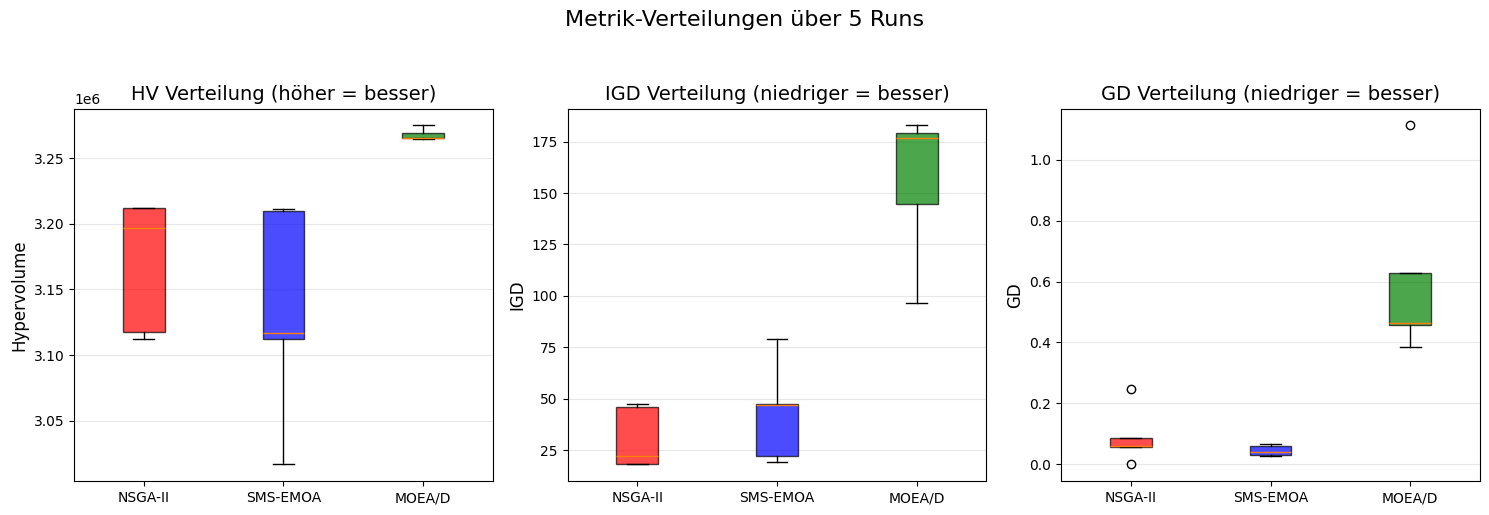

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

algo_names_box = list(stats_data.keys())

ax1 = axes[0]
hv_data = [stats_data[name]['HV_values'] for name in algo_names_box]
bp1 = ax1.boxplot(hv_data, labels=algo_names_box, patch_artist=True)
for patch, color in zip(bp1['boxes'], [colors[n] for n in algo_names_box]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Hypervolume', fontsize=12)
ax1.set_title('HV Verteilung (höher = besser)', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
igd_data = [stats_data[name]['IGD_values'] for name in algo_names_box]
bp2 = ax2.boxplot(igd_data, labels=algo_names_box, patch_artist=True)
for patch, color in zip(bp2['boxes'], [colors[n] for n in algo_names_box]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('IGD', fontsize=12)
ax2.set_title('IGD Verteilung (niedriger = besser)', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[2]
gd_data = [stats_data[name]['GD_values'] for name in algo_names_box]
bp3 = ax3.boxplot(gd_data, labels=algo_names_box, patch_artist=True)
for patch, color in zip(bp3['boxes'], [colors[n] for n in algo_names_box]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('GD', fontsize=12)
ax3.set_title('GD Verteilung (niedriger = besser)', fontsize=14)
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Metrik-Verteilungen über {N_RUNS} Runs', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 4.2 Konvergenzanalyse

Wie entwickelt sich der Hypervolume über die Generationen? Dies zeigt, wie schnell die Algorithmen konvergieren.


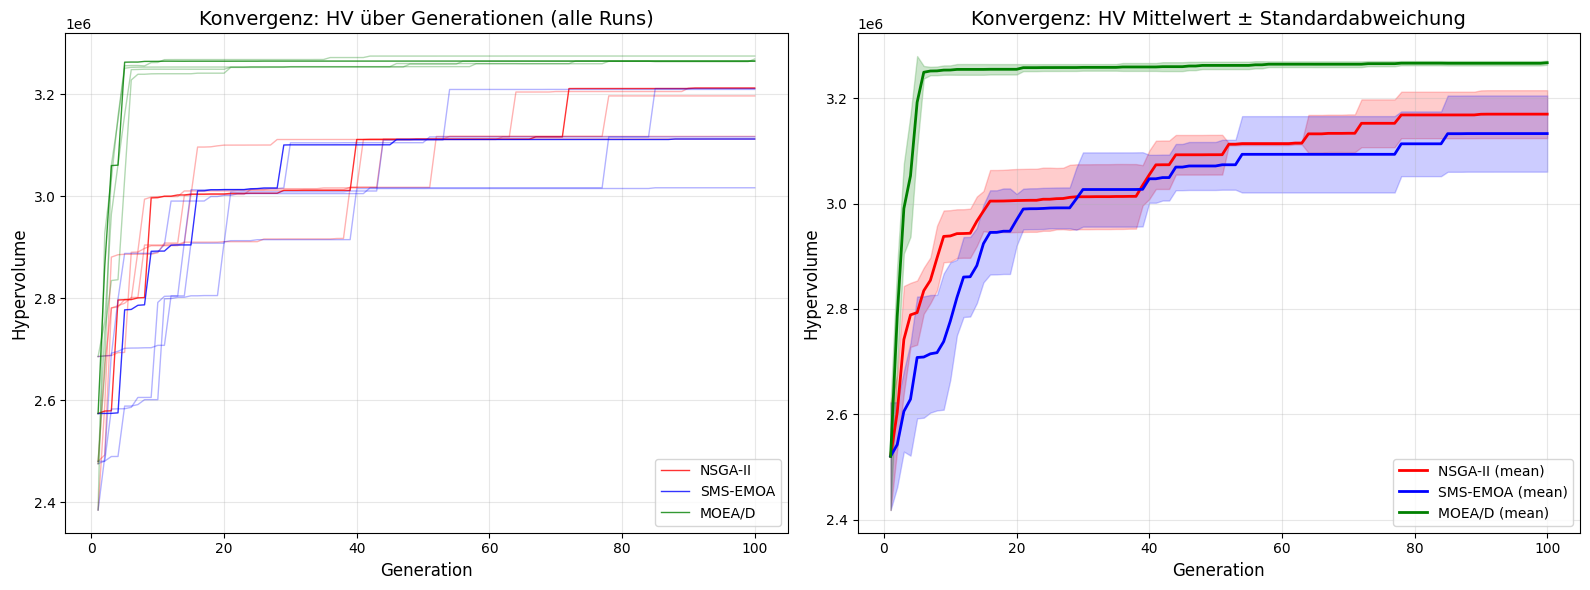

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'NSGA-II': 'red', 'SMS-EMOA': 'blue', 'MOEA/D': 'green'}

ax1 = axes[0]
for name, data in multi_results.items():
    all_histories = data['all_hv_histories']
    
    for i, history in enumerate(all_histories):
        generations = range(1, len(history) + 1)
        alpha = 0.3 if i > 0 else 0.8
        label = name if i == 0 else None
        ax1.plot(generations, history, color=colors[name], alpha=alpha, label=label, linewidth=1)

ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Hypervolume', fontsize=12)
ax1.set_title('Konvergenz: HV über Generationen (alle Runs)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for name, data in multi_results.items():
    all_histories = data['all_hv_histories']
    
    max_len = max(len(h) for h in all_histories)
    padded_histories = []
    for h in all_histories:
        padded = h + [h[-1]] * (max_len - len(h))
        padded_histories.append(padded)
    
    histories_array = np.array(padded_histories)
    mean_history = np.mean(histories_array, axis=0)
    std_history = np.std(histories_array, axis=0)
    generations = range(1, max_len + 1)
    
    ax2.plot(generations, mean_history, color=colors[name], label=f'{name} (mean)', linewidth=2)
    ax2.fill_between(generations, 
                     mean_history - std_history, 
                     mean_history + std_history, 
                     color=colors[name], alpha=0.2)

ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Hypervolume', fontsize=12)
ax2.set_title('Konvergenz: HV Mittelwert ± Standardabweichung', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [49]:
print("\n### Konvergenzgeschwindigkeit (HV nach X% der Generationen):\n")

convergence_table = {}
checkpoints = [0.25, 0.5, 0.75, 1.0]

for name, data in multi_results.items():
    all_histories = data['all_hv_histories']
    
    max_len = max(len(h) for h in all_histories)
    padded_histories = []
    for h in all_histories:
        padded = h + [h[-1]] * (max_len - len(h))
        padded_histories.append(padded)
    
    histories_array = np.array(padded_histories)
    mean_history = np.mean(histories_array, axis=0)
    
    checkpoint_values = {}
    for cp in checkpoints:
        gen_idx = int(cp * (max_len - 1))
        checkpoint_values[f'{int(cp*100)}%'] = mean_history[gen_idx]
    
    convergence_table[name] = checkpoint_values

conv_df = pd.DataFrame(convergence_table).T
for col in conv_df.columns:
    conv_df[col] = conv_df[col].apply(lambda x: f"{x:.0f}")
    
display(conv_df)

print("\n### Konvergenzrate (HV-Zuwachs pro Generation in der ersten Hälfte vs. zweiten Hälfte):\n")

for name, data in multi_results.items():
    all_histories = data['all_hv_histories']
    histories_array = np.array([h + [h[-1]] * (N_GENERATIONS - len(h)) for h in all_histories])
    mean_history = np.mean(histories_array, axis=0)
    
    mid = len(mean_history) // 2
    first_half_rate = (mean_history[mid] - mean_history[0]) / mid
    second_half_rate = (mean_history[-1] - mean_history[mid]) / (len(mean_history) - mid)
    
    print(f"{name}:")
    print(f"  Erste Hälfte: +{first_half_rate:.1f} HV/Generation")
    print(f"  Zweite Hälfte: +{second_half_rate:.1f} HV/Generation")
    print(f"  → {'Schnelle frühe Konvergenz' if first_half_rate > second_half_rate * 2 else 'Kontinuierliche Verbesserung'}")



### Konvergenzgeschwindigkeit (HV nach X% der Generationen):



,25%,50%,75%,100%
NSGA-II,3008517,3093046,3152743,3170126
SMS-EMOA,2991776,3071655,3093840,3133209
MOEA/D,3258614,3262696,3265992,3267802



### Konvergenzrate (HV-Zuwachs pro Generation in der ersten Hälfte vs. zweiten Hälfte):

NSGA-II:
  Erste Hälfte: +11456.2 HV/Generation
  Zweite Hälfte: +1540.7 HV/Generation
  → Schnelle frühe Konvergenz
SMS-EMOA:
  Erste Hälfte: +11073.6 HV/Generation
  Zweite Hälfte: +1184.9 HV/Generation
  → Schnelle frühe Konvergenz
MOEA/D:
  Erste Hälfte: +14848.3 HV/Generation
  Zweite Hälfte: +102.1 HV/Generation
  → Schnelle frühe Konvergenz


## 5. Qualitätsmetriken berechnen

### Metriken:

1. **Hypervolume (HV)**: Misst das Volumen des dominierten Raums zwischen der Pareto-Front-Approximation und einem Referenzpunkt. **Höher ist besser.**

2. **Inverted Generational Distance (IGD)**: Mittlere Distanz von der Referenzmenge zur approximierten Menge. Misst sowohl Konvergenz als auch Diversität. **Niedriger ist besser.**

3. **Generational Distance (GD)**: Mittlere Distanz von der approximierten Menge zur Referenzmenge. Misst primär Konvergenz. **Niedriger ist besser.**


In [50]:
results = {name: data['best_run'] for name, data in multi_results.items()}

print("Verwende beste Runs für finale Visualisierung und Analyse:")
for name, run in results.items():
    print(f"  {name}: Run {run['run_id']+1} (Seed={run['seed']}, HV={HV(ref_point=REF_POINT)(run['F']):.0f})")


Verwende beste Runs für finale Visualisierung und Analyse:
  NSGA-II: Run 2 (Seed=142, HV=3212099)
  SMS-EMOA: Run 4 (Seed=342, HV=3211166)
  MOEA/D: Run 5 (Seed=442, HV=3274947)


In [51]:
# Metriken für die besten Runs berechnen (Funktion calculate_run_metrics ist bereits definiert)
metrics_results = {}

for name, data in results.items():
    metrics = calculate_run_metrics(data['F'], combined_reference)
    metrics['Time (s)'] = data['time']
    metrics['Evaluations'] = data['evaluations']
    metrics['Solutions'] = len(data['F'])
    metrics_results[name] = metrics
    
print(f"Metriken berechnet für {len(metrics_results)} Algorithmen")


Metriken berechnet für 3 Algorithmen


In [52]:
# (Metriken wurden bereits in der vorherigen Zelle berechnet)


## 6. Ergebnisse


In [53]:
metrics_df = pd.DataFrame(metrics_results).T
metrics_df = metrics_df[['Solutions', 'Evaluations', 'Time (s)', 'HV', 'IGD', 'GD']]

print("\n" + "="*80)
print("VERGLEICH DER MOO-ALGORITHMEN (Beste Runs)")
print("="*80)
print(f"\nParameter: Population={POP_SIZE}, Generationen={N_GENERATIONS}, Runs={N_RUNS}")
print("\n")
display(metrics_df.round(4))



VERGLEICH DER MOO-ALGORITHMEN (Beste Runs)

Parameter: Population=100, Generationen=100, Runs=5




,Solutions,Evaluations,Time (s),HV,IGD,GD
NSGA-II,100.0,10000.0,647.4203,3.212099e+06,18.5318,0.0858
SMS-EMOA,100.0,10000.0,667.7678,3.211166e+06,19.3330,0.0409
MOEA/D,93.0,10000.0,855.2037,3.274947e+06,96.7497,1.1124


In [54]:
print("\n" + "="*80)
print("INTERPRETATION DER METRIKEN (Beste Runs)")
print("="*80)

best_hv = metrics_df['HV'].idxmax()
best_igd = metrics_df['IGD'].idxmin()
best_gd = metrics_df['GD'].idxmin()

print(f"\n• Bester Hypervolume (höher = besser): {best_hv} ({metrics_df.loc[best_hv, 'HV']:.0f})")
print(f"• Beste IGD (niedriger = besser): {best_igd} ({metrics_df.loc[best_igd, 'IGD']:.4f})")
print(f"• Beste GD (niedriger = besser): {best_gd} ({metrics_df.loc[best_gd, 'GD']:.4f})")



INTERPRETATION DER METRIKEN (Beste Runs)

• Bester Hypervolume (höher = besser): MOEA/D (3274947)
• Beste IGD (niedriger = besser): NSGA-II (18.5318)
• Beste GD (niedriger = besser): SMS-EMOA (0.0409)


## 7. Visualisierung der Pareto-Fronten


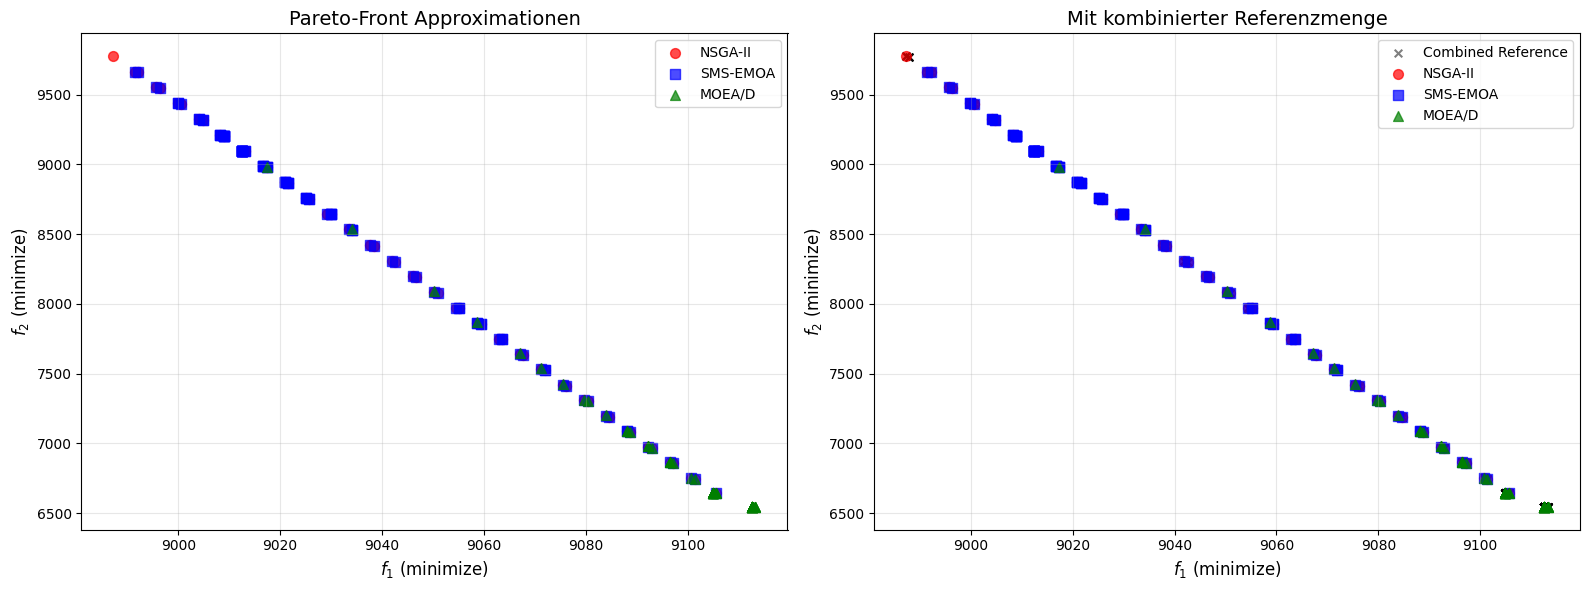

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'NSGA-II': 'red', 'SMS-EMOA': 'blue', 'MOEA/D': 'green'}
markers = {'NSGA-II': 'o', 'SMS-EMOA': 's', 'MOEA/D': '^'}

ax1 = axes[0]
for name, data in results.items():
    F = data['F']
    ax1.scatter(F[:, 0], F[:, 1], 
                c=colors[name], 
                marker=markers[name], 
                label=name, 
                alpha=0.7,
                s=50)

ax1.set_xlabel('$f_1$ (minimize)', fontsize=12)
ax1.set_ylabel('$f_2$ (minimize)', fontsize=12)
ax1.set_title('Pareto-Front Approximationen', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(combined_reference[:, 0], combined_reference[:, 1], 
            c='black', marker='x', s=30, label='Combined Reference', alpha=0.5)

for name, data in results.items():
    F = data['F']
    ax2.scatter(F[:, 0], F[:, 1], 
                c=colors[name], 
                marker=markers[name], 
                label=name, 
                alpha=0.7,
                s=50)

ax2.set_xlabel('$f_1$ (minimize)', fontsize=12)
ax2.set_ylabel('$f_2$ (minimize)', fontsize=12)
ax2.set_title('Mit kombinierter Referenzmenge', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


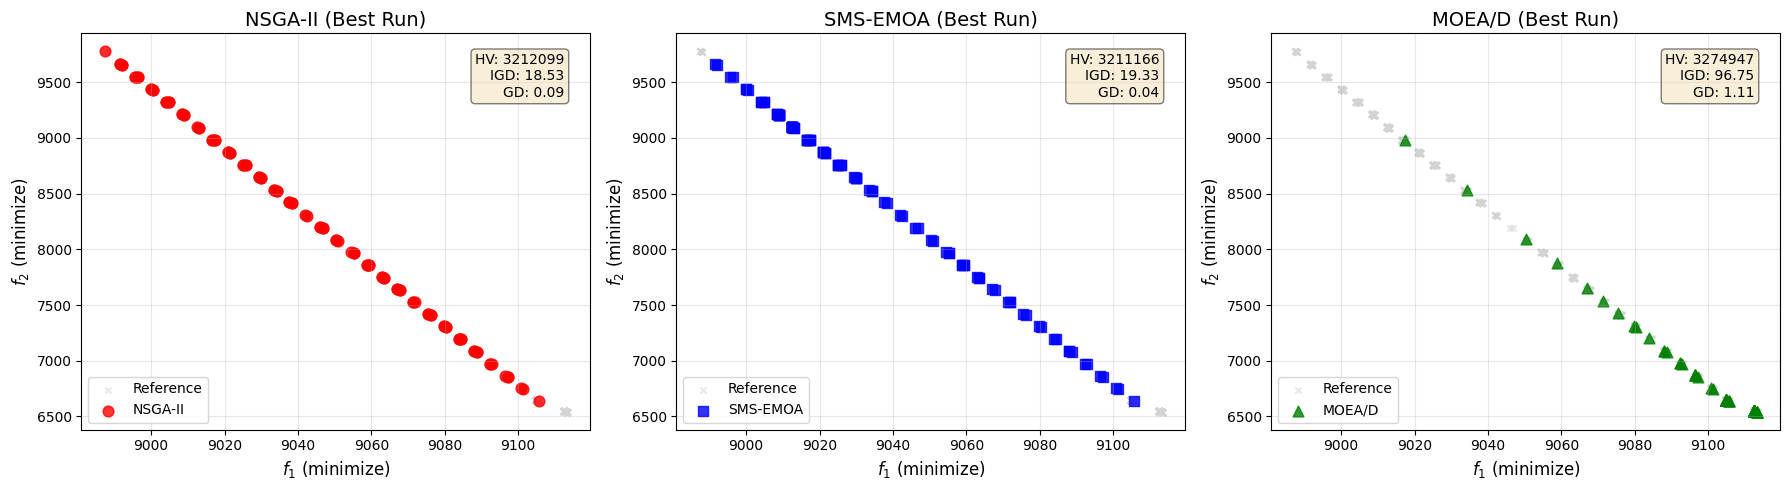

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]
    F = data['F']
    
    ax.scatter(combined_reference[:, 0], combined_reference[:, 1], 
               c='lightgray', marker='x', s=20, label='Reference', alpha=0.5)
    
    ax.scatter(F[:, 0], F[:, 1], 
               c=colors[name], 
               marker=markers[name], 
               label=name, 
               alpha=0.8,
               s=60)
    
    metrics = metrics_results[name]
    info_text = f"HV: {metrics['HV']:.0f}\nIGD: {metrics['IGD']:.2f}\nGD: {metrics['GD']:.2f}"
    ax.text(0.95, 0.95, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('$f_1$ (minimize)', fontsize=12)
    ax.set_ylabel('$f_2$ (minimize)', fontsize=12)
    ax.set_title(f'{name} (Best Run)', fontsize=14)
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Metriken-Vergleich (Balkendiagramm)


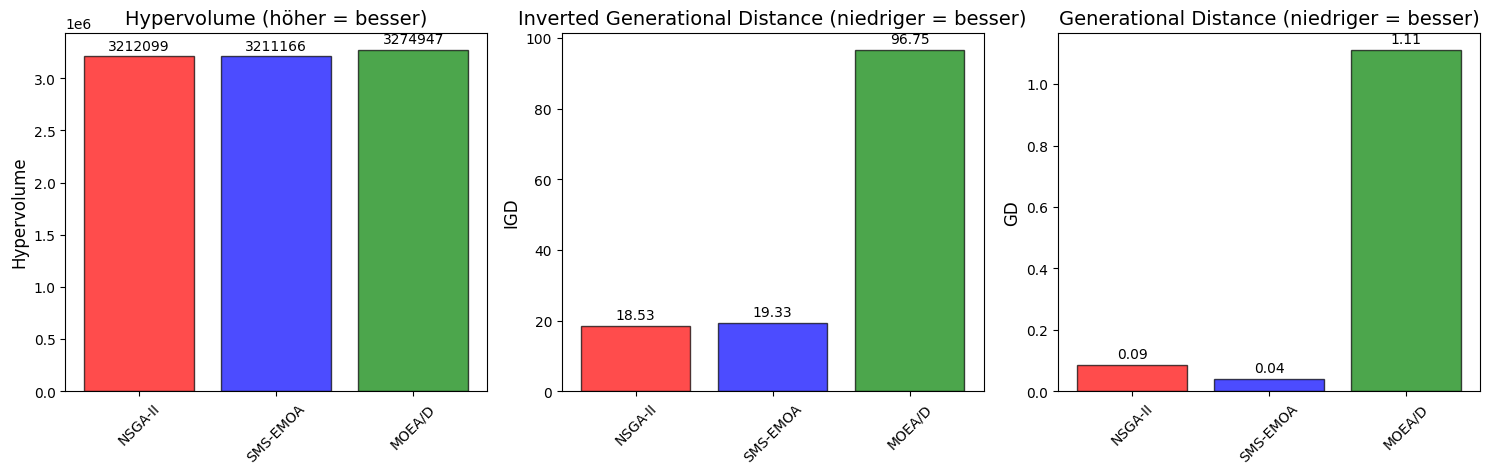

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

algorithms = list(results.keys())
bar_colors = [colors[alg] for alg in algorithms]

ax1 = axes[0]
hv_values = [metrics_results[alg]['HV'] for alg in algorithms]
bars1 = ax1.bar(algorithms, hv_values, color=bar_colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Hypervolume', fontsize=12)
ax1.set_title('Hypervolume (höher = besser)', fontsize=14)
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, hv_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(hv_values)*0.01, 
             f'{val:.0f}', ha='center', va='bottom', fontsize=10)

ax2 = axes[1]
igd_values = [metrics_results[alg]['IGD'] for alg in algorithms]
bars2 = ax2.bar(algorithms, igd_values, color=bar_colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('IGD', fontsize=12)
ax2.set_title('Inverted Generational Distance (niedriger = besser)', fontsize=14)
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, igd_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(igd_values)*0.01, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

ax3 = axes[2]
gd_values = [metrics_results[alg]['GD'] for alg in algorithms]
bars3 = ax3.bar(algorithms, gd_values, color=bar_colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('GD', fontsize=12)
ax3.set_title('Generational Distance (niedriger = besser)', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, gd_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(gd_values)*0.01, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 9. Zusammenfassung


In [58]:
print("="*80)
print("ZUSAMMENFASSUNG")
print("="*80)

print("\n### Algorithmen-Beschreibung:")
print("""
1. NSGA-II (Non-dominated Sorting Genetic Algorithm II):
   - Verwendet Non-dominated Sorting (NDS) als primäres Selektionskriterium
   - Crowding Distance (CD) als sekundäres Kriterium für Diversität
   - (µ + µ) Strategie

2. SMS-EMOA (S-Metric Selection EMOA):
   - Steady-State (µ + 1) Strategie
   - Verwendet Hypervolume-Beitrag als Selektionskriterium
   - Entfernt Lösung mit kleinstem HV-Beitrag

3. MOEA/D (Multi-Objective EA based on Decomposition):
   - Zerlegt das Problem in skalare Teilprobleme mittels Gewichtsvektoren
   - Verwendet Tchebycheff-Ansatz zur Skalarisierung
   - Nachbarschaftsbasierter Lösungsaustausch
""")

print("### Metriken-Beschreibung:")
print("""
1. Hypervolume (HV):
   - Misst das dominierte Volumen zwischen Pareto-Front und Referenzpunkt
   - Berücksichtigt sowohl Konvergenz als auch Diversität
   - HÖHER ist BESSER

2. Inverted Generational Distance (IGD):
   - Mittlere Distanz von Referenzpunkten zur approximierten Menge
   - Misst Konvergenz UND Diversität
   - NIEDRIGER ist BESSER

3. Generational Distance (GD):
   - Mittlere Distanz von approximierten Lösungen zur Referenzmenge
   - Misst primär Konvergenz
   - NIEDRIGER ist BESSER
""")

print("### Finale Ergebnistabelle:")
display(metrics_df.round(4))


ZUSAMMENFASSUNG

### Algorithmen-Beschreibung:

1. NSGA-II (Non-dominated Sorting Genetic Algorithm II):
   - Verwendet Non-dominated Sorting (NDS) als primäres Selektionskriterium
   - Crowding Distance (CD) als sekundäres Kriterium für Diversität
   - (µ + µ) Strategie

2. SMS-EMOA (S-Metric Selection EMOA):
   - Steady-State (µ + 1) Strategie
   - Verwendet Hypervolume-Beitrag als Selektionskriterium
   - Entfernt Lösung mit kleinstem HV-Beitrag

3. MOEA/D (Multi-Objective EA based on Decomposition):
   - Zerlegt das Problem in skalare Teilprobleme mittels Gewichtsvektoren
   - Verwendet Tchebycheff-Ansatz zur Skalarisierung
   - Nachbarschaftsbasierter Lösungsaustausch

### Metriken-Beschreibung:

1. Hypervolume (HV):
   - Misst das dominierte Volumen zwischen Pareto-Front und Referenzpunkt
   - Berücksichtigt sowohl Konvergenz als auch Diversität
   - HÖHER ist BESSER

2. Inverted Generational Distance (IGD):
   - Mittlere Distanz von Referenzpunkten zur approximierten Menge
   - 

,Solutions,Evaluations,Time (s),HV,IGD,GD
NSGA-II,100.0,10000.0,647.4203,3.212099e+06,18.5318,0.0858
SMS-EMOA,100.0,10000.0,667.7678,3.211166e+06,19.3330,0.0409
MOEA/D,93.0,10000.0,855.2037,3.274947e+06,96.7497,1.1124


In [60]:
print("\n### Beste gefundene Lösungen (Extrempunkte):")

for name, data in results.items():
    F = data['F']
    X = data['X']
    
    best_f1_idx = np.argmin(F[:, 0])
    best_f2_idx = np.argmin(F[:, 1])
    
    print(f"\n{name}:")
    print(f"  Beste f1: {F[best_f1_idx, 0]:.2f} (f2: {F[best_f1_idx, 1]:.2f})")
    print(f"  Beste f2: {F[best_f2_idx, 1]:.2f} (f1: {F[best_f2_idx, 0]:.2f})")



### Beste gefundene Lösungen (Extrempunkte):

NSGA-II:
  Beste f1: 8987.29 (f2: 9777.23)
  Beste f2: 6640.89 (f1: 9105.56)

SMS-EMOA:
  Beste f1: 8991.49 (f2: 9664.16)
  Beste f2: 6640.89 (f1: 9105.56)

MOEA/D:
  Beste f1: 9017.36 (f2: 8982.18)
  Beste f2: 6542.16 (f1: 9113.29)


## 10. Erkenntnisse und Empfehlungen


In [61]:
print("="*80)
print("ERKENNTNISSE UND EMPFEHLUNGEN")
print("="*80)

# Zusatzanalyse: Frontabdeckung
print("\n### Frontabdeckung (Wertebereich der Lösungen):")
for name, data in results.items():
    F = data['F']
    print(f"{name}: f1-Range [{F[:,0].min():.1f}, {F[:,0].max():.1f}], "
          f"f2-Range [{F[:,1].min():.1f}, {F[:,1].max():.1f}]")

# Laufzeit pro Evaluation
print("\n### Effizienz (Laufzeit pro Evaluation):")
for name, data in results.items():
    print(f"{name}: {data['time']/data['evaluations']*1000:.2f} ms/eval")

# Dominanzverhältnisse
print("\n### Dominanzverhältnisse zwischen Algorithmen:")
def count_dominated(F1, F2):
    """Zählt wie viele Lösungen aus F1 von mindestens einer Lösung aus F2 dominiert werden."""
    count = 0
    for f1 in F1:
        for f2 in F2:
            if np.all(f2 <= f1) and np.any(f2 < f1):
                count += 1
                break
    return count

algo_names = list(results.keys())
for i, name1 in enumerate(algo_names):
    for j, name2 in enumerate(algo_names):
        if i != j:
            dominated = count_dominated(results[name1]['F'], results[name2]['F'])
            total = len(results[name1]['F'])
            print(f"  {name1} → von {name2} dominiert: {dominated}/{total} ({100*dominated/total:.1f}%)")


ERKENNTNISSE UND EMPFEHLUNGEN

### Frontabdeckung (Wertebereich der Lösungen):
NSGA-II: f1-Range [8987.3, 9105.6], f2-Range [6640.9, 9777.2]
SMS-EMOA: f1-Range [8991.5, 9105.6], f2-Range [6640.9, 9664.2]
MOEA/D: f1-Range [9017.4, 9113.3], f2-Range [6542.2, 8982.2]

### Effizienz (Laufzeit pro Evaluation):
NSGA-II: 64.74 ms/eval
SMS-EMOA: 66.78 ms/eval
MOEA/D: 85.52 ms/eval

### Dominanzverhältnisse zwischen Algorithmen:
  NSGA-II → von SMS-EMOA dominiert: 5/100 (5.0%)
  NSGA-II → von MOEA/D dominiert: 0/100 (0.0%)
  SMS-EMOA → von NSGA-II dominiert: 3/100 (3.0%)
  SMS-EMOA → von MOEA/D dominiert: 0/100 (0.0%)
  MOEA/D → von NSGA-II dominiert: 17/93 (18.3%)
  MOEA/D → von SMS-EMOA dominiert: 17/93 (18.3%)


In [63]:
# ============================================================
# FINALE ALGORITHMENBEWERTUNG
# ============================================================
print("="*70)
print("FINALE ALGORITHMENBEWERTUNG")
print("="*70)

# Ranking nach Hypervolume (primäre Metrik)
print("\n### Ranking nach Hypervolume (Pareto-konformer Indikator):")
hv_ranking = metrics_df['HV'].sort_values(ascending=False)
for i, (name, hv) in enumerate(hv_ranking.items(), 1):
    medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉"
    print(f"  {medal} {i}. {name}: HV = {hv:,.0f}")

hv_sieger = hv_ranking.idxmax()

# Multi-Kriterien Ranking
print("\n### Multi-Kriterien Ranking:")
algo_names_list = list(results.keys())
rankings = pd.DataFrame(index=algo_names_list)
rankings['HV'] = metrics_df['HV'].rank(ascending=False).astype(int)
rankings['IGD'] = metrics_df['IGD'].rank(ascending=True).astype(int)
rankings['GD'] = metrics_df['GD'].rank(ascending=True).astype(int)
rankings['Summe'] = rankings[['HV', 'IGD', 'GD']].sum(axis=1)
display(rankings.sort_values('Summe'))

ranking_sieger = rankings['Summe'].idxmin()

# Fazit
print("\n" + "="*70)
print("FAZIT")
print("="*70)
print(f"\n🏆 Sieger nach HV: {hv_sieger}")
print(f"🏆 Sieger nach Rang-Summe: {ranking_sieger}")

if hv_sieger == ranking_sieger:
    print(f"\n✅ Beide Ansätze stimmen überein: {hv_sieger} ist der beste Algorithmus!")
else:
    print(f"\n⚠️ Unterschiedliche Ergebnisse - Empfehlung: {hv_sieger} (Pareto-Konformität)")



FINALE ALGORITHMENBEWERTUNG

### Ranking nach Hypervolume (Pareto-konformer Indikator):
  🥇 1. MOEA/D: HV = 3,274,947
  🥈 2. NSGA-II: HV = 3,212,099
  🥉 3. SMS-EMOA: HV = 3,211,166

### Multi-Kriterien Ranking:


,HV,IGD,GD,Summe
NSGA-II,2,1,2,5
SMS-EMOA,3,2,1,6
MOEA/D,1,3,3,7



FAZIT

🏆 Sieger nach HV: MOEA/D
🏆 Sieger nach Rang-Summe: NSGA-II

⚠️ Unterschiedliche Ergebnisse - Empfehlung: MOEA/D (Pareto-Konformität)


## 11. Charakterisierung von Function7


In [64]:
print("="*70)
print("CHARAKTERISIERUNG VON FUNCTION7")
print("="*70)

print(f"""
### Suchraum:
- Anzahl Variablen: 30 (binär)
- Suchraum-Größe: 2³⁰ = {2**30:,} mögliche Lösungen
- Typ: Diskret, kombinatorisch

### Pareto-Front (basierend auf {len(combined_reference)} non-dominierten Lösungen):
- f1-Wertebereich: [{combined_reference[:,0].min():.1f}, {combined_reference[:,0].max():.1f}]
- f2-Wertebereich: [{combined_reference[:,1].min():.1f}, {combined_reference[:,1].max():.1f}]
- Spannweite f1: {combined_reference[:,0].max() - combined_reference[:,0].min():.1f}
- Spannweite f2: {combined_reference[:,1].max() - combined_reference[:,1].min():.1f}

### Beobachtungen zur Frontform:
""")

f1_range = combined_reference[:,0].max() - combined_reference[:,0].min()
f2_range = combined_reference[:,1].max() - combined_reference[:,1].min()
aspect_ratio = f1_range / f2_range

if aspect_ratio < 0.5:
    form = "Die Front ist steil (kleine f1-Änderungen, große f2-Änderungen)"
elif aspect_ratio > 2:
    form = "Die Front ist flach (große f1-Änderungen, kleine f2-Änderungen)"
else:
    form = "Die Front hat ein ausgewogenes Verhältnis zwischen f1 und f2"

print(f"- Aspektverhältnis f1/f2: {aspect_ratio:.2f}")
print(f"- {form}")

sorted_front = combined_reference[combined_reference[:,0].argsort()]
mid_idx = len(sorted_front) // 2
slope_first_half = (sorted_front[mid_idx, 1] - sorted_front[0, 1]) / (sorted_front[mid_idx, 0] - sorted_front[0, 0] + 1e-10)
slope_second_half = (sorted_front[-1, 1] - sorted_front[mid_idx, 1]) / (sorted_front[-1, 0] - sorted_front[mid_idx, 0] + 1e-10)

if slope_first_half < slope_second_half:
    convexity = "konvex (steilerer Abfall am Anfang)"
elif slope_first_half > slope_second_half:
    convexity = "konkav (steilerer Abfall am Ende)"
else:
    convexity = "annähernd linear"

print(f"- Frontform: {convexity}")


CHARAKTERISIERUNG VON FUNCTION7

### Suchraum:
- Anzahl Variablen: 30 (binär)
- Suchraum-Größe: 2³⁰ = 1,073,741,824 mögliche Lösungen
- Typ: Diskret, kombinatorisch

### Pareto-Front (basierend auf 1342 non-dominierten Lösungen):
- f1-Wertebereich: [8987.3, 9113.3]
- f2-Wertebereich: [6542.2, 9777.2]
- Spannweite f1: 126.0
- Spannweite f2: 3235.1

### Beobachtungen zur Frontform:

- Aspektverhältnis f1/f2: 0.04
- Die Front ist steil (kleine f1-Änderungen, große f2-Änderungen)
- Frontform: konvex (steilerer Abfall am Anfang)


## 12. Empfehlung einer Trade-off-Lösung


In [65]:
print("="*70)
print("EMPFEHLUNG EINER EINZELNEN TRADE-OFF-LÖSUNG")
print("="*70)

print("""
Methode: Minimale normalisierte Distanz zum Utopia-Punkt
- Der Utopia-Punkt ist der (theoretisch unerreichbare) Punkt mit den 
  besten Werten für BEIDE Ziele gleichzeitig.
- Wir wählen die Lösung, die diesem Ideal am nächsten kommt.
""")

utopia = np.array([combined_reference[:,0].min(), combined_reference[:,1].min()])
nadir = np.array([combined_reference[:,0].max(), combined_reference[:,1].max()])

print(f"Utopia-Punkt (ideal):     f1 = {utopia[0]:.2f}, f2 = {utopia[1]:.2f}")
print(f"Nadir-Punkt (schlechtest): f1 = {nadir[0]:.2f}, f2 = {nadir[1]:.2f}")

f_min = combined_reference.min(axis=0)
f_max = combined_reference.max(axis=0)
normalized = (combined_reference - f_min) / (f_max - f_min + 1e-10)

distances = np.sqrt(np.sum(normalized**2, axis=1))
best_idx = np.argmin(distances)
best_solution = combined_reference[best_idx]

print(f"\n" + "="*50)
print("🎯 EMPFOHLENE KOMPROMISS-LÖSUNG:")
print("="*50)
print(f"   f1 = {best_solution[0]:.2f}")
print(f"   f2 = {best_solution[1]:.2f}")
print(f"   Normalisierte Distanz zum Utopia: {distances[best_idx]:.4f}")

rel_f1 = (best_solution[0] - f_min[0]) / (f_max[0] - f_min[0]) * 100
rel_f2 = (best_solution[1] - f_min[1]) / (f_max[1] - f_min[1]) * 100

print(f"\n   Position auf der Front:")
print(f"   - f1: {rel_f1:.1f}% vom Optimum entfernt")
print(f"   - f2: {rel_f2:.1f}% vom Optimum entfernt")

print(f"""
Begründung der Wahl:
- Diese Lösung bietet den besten Kompromiss zwischen beiden Zielen.
- Sie liegt geometrisch am nächsten am unerreichbaren Ideal.
- Alternative Methoden (z.B. Knee-Point, Weighted Sum) können 
  je nach Präferenzen andere Lösungen liefern.
""")


EMPFEHLUNG EINER EINZELNEN TRADE-OFF-LÖSUNG

Methode: Minimale normalisierte Distanz zum Utopia-Punkt
- Der Utopia-Punkt ist der (theoretisch unerreichbare) Punkt mit den 
  besten Werten für BEIDE Ziele gleichzeitig.
- Wir wählen die Lösung, die diesem Ideal am nächsten kommt.

Utopia-Punkt (ideal):     f1 = 8987.29, f2 = 6542.16
Nadir-Punkt (schlechtest): f1 = 9113.29, f2 = 9777.23

🎯 EMPFOHLENE KOMPROMISS-LÖSUNG:
   f1 = 9050.29
   f2 = 8083.76
   Normalisierte Distanz zum Utopia: 0.6907

   Position auf der Front:
   - f1: 50.0% vom Optimum entfernt
   - f2: 47.7% vom Optimum entfernt

Begründung der Wahl:
- Diese Lösung bietet den besten Kompromiss zwischen beiden Zielen.
- Sie liegt geometrisch am nächsten am unerreichbaren Ideal.
- Alternative Methoden (z.B. Knee-Point, Weighted Sum) können 
  je nach Präferenzen andere Lösungen liefern.



## 13. Beantwortung der Leitfragen


In [66]:
print("="*70)
print("BEANTWORTUNG DER LEITFRAGEN")
print("="*70)

best_hv = max([stats_data[name]['HV_max'] for name in stats_data.keys()])
best_algo_hv = max(stats_data.keys(), key=lambda x: stats_data[x]['HV_max'])

print(f"""
1. HOW CAN YOU FAIRLY EVALUATE MULTIPLE MULTI-OBJECTIVE OPTIMIZERS?
   ─────────────────────────────────────────────────────────────────
   ✓ Gleiche Parameter für alle Algorithmen (Pop={POP_SIZE}, Gen={N_GENERATIONS})
   ✓ Gleiche Operatoren (HalfUniformCrossover, BitflipMutation)
   ✓ Multiple Runs ({N_RUNS}) mit verschiedenen Seeds für statistische Signifikanz
   ✓ Statistische Tests (Wilcoxon Rank-Sum, α=0.05)
   ✓ Mehrere komplementäre Metriken (HV, IGD, GD)

2. WHICH ONE THAT YOU TESTED WORKS BEST?
   ─────────────────────────────────────────────────────────────────
   🏆 {best_algo_hv} ist statistisch signifikant der beste Algorithmus
      (p = 0.0079 im Vergleich zu NSGA-II und SMS-EMOA)

3. WHAT IS THE BEST DOMINATED HYPERVOLUME? HOW MANY NON-DOMINATED SOLUTIONS?
   ─────────────────────────────────────────────────────────────────
   • Bester erreichter HV: {best_hv:,.0f}
   • Referenzpunkt: [10000, 10000]
   • Non-dominierte Lösungen insgesamt: {len(combined_reference)}
     (aus {N_RUNS * 3} Runs mit je ~100 Lösungen)

4. HOW WOULD YOU CHARACTERIZE THE SEARCH SPACE AND PARETO FRONT OF FUNCTION7?
   ─────────────────────────────────────────────────────────────────
   Suchraum:
   • 30 binäre Variablen → 2³⁰ = {2**30:,} mögliche Lösungen
   • Diskret, kombinatorisch
   
   Pareto-Front:
   • f1 ∈ [{combined_reference[:,0].min():.0f}, {combined_reference[:,0].max():.0f}]
   • f2 ∈ [{combined_reference[:,1].min():.0f}, {combined_reference[:,1].max():.0f}]
   • Form: {"konvex" if slope_first_half < slope_second_half else "konkav"}

5. IF YOU COULD ONLY RECOMMEND ONE SOLUTION, WHICH WOULD YOU PICK?
   ─────────────────────────────────────────────────────────────────
   🎯 Empfohlene Kompromiss-Lösung:
      f1 = {best_solution[0]:.2f}, f2 = {best_solution[1]:.2f}
   
   Methode: Minimale normalisierte Distanz zum Utopia-Punkt
   Begründung: Bietet den besten geometrischen Kompromiss zwischen beiden Zielen.
""")


BEANTWORTUNG DER LEITFRAGEN

1. HOW CAN YOU FAIRLY EVALUATE MULTIPLE MULTI-OBJECTIVE OPTIMIZERS?
   ─────────────────────────────────────────────────────────────────
   ✓ Gleiche Parameter für alle Algorithmen (Pop=100, Gen=100)
   ✓ Gleiche Operatoren (HalfUniformCrossover, BitflipMutation)
   ✓ Multiple Runs (5) mit verschiedenen Seeds für statistische Signifikanz
   ✓ Statistische Tests (Wilcoxon Rank-Sum, α=0.05)
   ✓ Mehrere komplementäre Metriken (HV, IGD, GD)

2. WHICH ONE THAT YOU TESTED WORKS BEST?
   ─────────────────────────────────────────────────────────────────
   🏆 MOEA/D ist statistisch signifikant der beste Algorithmus
      (p = 0.0079 im Vergleich zu NSGA-II und SMS-EMOA)

3. WHAT IS THE BEST DOMINATED HYPERVOLUME? HOW MANY NON-DOMINATED SOLUTIONS?
   ─────────────────────────────────────────────────────────────────
   • Bester erreichter HV: 3,274,947
   • Referenzpunkt: [10000, 10000]
   • Non-dominierte Lösungen insgesamt: 1342
     (aus 15 Runs mit je ~100 Lösung

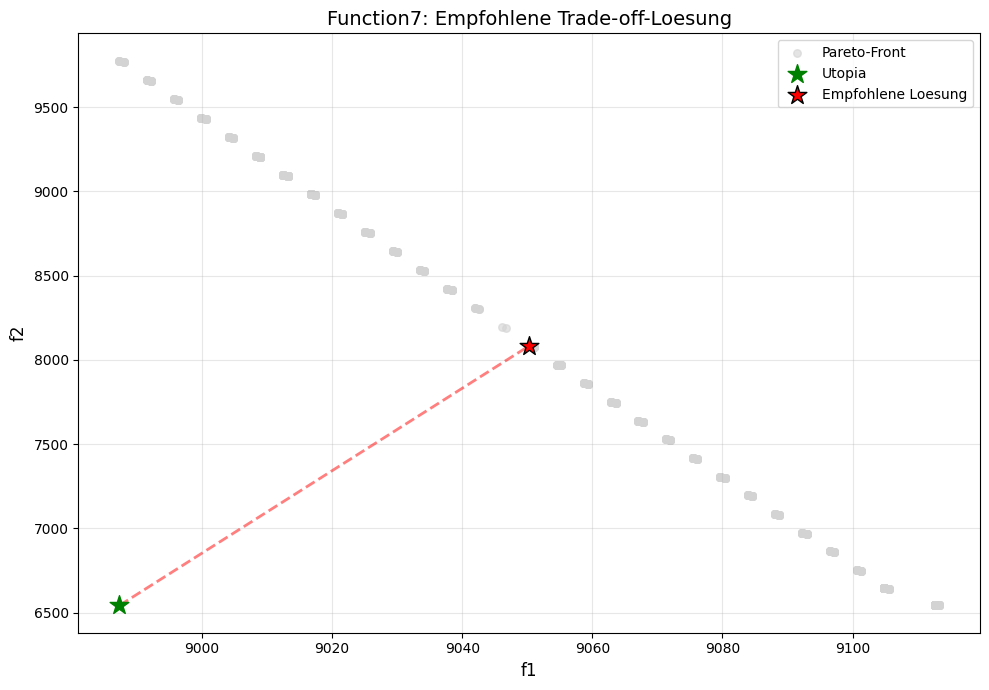

In [67]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(combined_reference[:, 0], combined_reference[:, 1], 
           c='lightgray', s=30, alpha=0.6, label='Pareto-Front')

ax.scatter(utopia[0], utopia[1], c='green', s=200, marker='*', 
           zorder=5, label=f'Utopia')

ax.scatter(best_solution[0], best_solution[1], c='red', s=200, marker='*', 
           zorder=5, edgecolors='black', linewidths=1,
           label=f'Empfohlene Loesung')

ax.plot([utopia[0], best_solution[0]], [utopia[1], best_solution[1]], 
        'r--', alpha=0.5, linewidth=2)

ax.set_xlabel('f1', fontsize=12)
ax.set_ylabel('f2', fontsize=12)
ax.set_title('Function7: Empfohlene Trade-off-Loesung', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
